# Granite based on local behavior (effects) for Kin8nm


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_kin8nm
from granite.decompositions import get_components_brute_force, get_regional_decompositions

### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [ ]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_kin8nm()
print(X.shape)
features.summary()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [ ]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

In [ ]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')
plt.show()

In [ ]:
# Pickle the model
dump(model, os.path.join("models", "kin8nm_gbt.joblib"))

**Start from here if you have already trained and dumped the model.**

In [ ]:
# Load the model
model = load(os.path.join("models", "kin8nm_gbt.joblib"))
test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

## Disagreement due to interactions: Marginal Pure-Full Effects (individual feature influence)

We can understand how an individual features impact the model response by computing their pure and full marginal effects.
We first compute the Anchored decomposition.

In [ ]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

In [ ]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (i,) is the main effect of feature i in the Anchored Decomposition
display(decomposition[(0,)].shape)

In [ ]:
from granite.plots import partial_dependence_plot

# Plot the PDP and the ICE curves
partial_dependence_plot(decomposition, background, features, centered=True, figsize=(15, 10), n_cols = 4)
plt.savefig("../figures/kin8nm_pure_full_global_all.pdf", bbox_inches="tight")

plt.show()

**Hour and temperature have the highers heterogeneity (besides workingday)**

In [ ]:

# Plot the PDP and the ICE curves
partial_dependence_plot(decomposition, background, features, idxs = [5, 6], centered=True, figsize=(5, 3))
plt.savefig("../figures/kin8nm_pure_full_global_main.pdf", bbox_inches='tight', dpi=300)

plt.show()
# Save the entire figure (all selected plots) as a PDF
##import matplotlib.pyplot as plt
#plt.savefig("../figures/bike_pure_full_global_main.pdf", bbox_inches="tight")  # tight layout
#plt.close()  # closes the figure to free memory

**We now perform GRANITE to minimize interactions from full to pure fo individual local effects of all features.**

In [ ]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# Option 1: We minimize all interactions
U = [(i,) for i in range(len(features))]
features_to_split_upon = [i for i in range(len(features))]

# We penalize all pure-vs-full effects of each feature, which ammounts to minimizing all interactions within the model
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=U
)
tree = FDTree(max_depth=3, features=features.select(features_to_split_upon), alpha=0.1, save_losses=True)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

In [ ]:
# Using regional backgrounds
larger_background = X_test[:3000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

In [ ]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                )

In [ ]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(15, 10), n_cols = 4)
plt.savefig("../figures/kin8nm_pure_full_regional_all.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/kin8nm_pure_full_regional_all_legend.pdf", bbox_inches='tight')

plt.show()

In [ ]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, idxs = [5, 6], centered=True, figsize=(6, 3), n_cols = 2)
plt.savefig("../figures/kin8nm_pure_full_regional_main.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/kin8nm_pure_full_regional_main_legend.pdf", bbox_inches='tight')

plt.show()

## Pure vs. Full for Interaction influence measures

In [60]:
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]

# Compute the Interventional Decomposition
decomposition = get_components_brute_force(
    lambda X: model.predict(X),  # use predict instead of calling the model directly
    background,
    background,
    features,
    interactions=2,
    show_bar=True
)
display(decomposition.keys())

Functional Decomposition: 8it [01:14,  9.27s/it]
Functional Decomposition: 28it [04:44, 10.15s/it]


dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)])

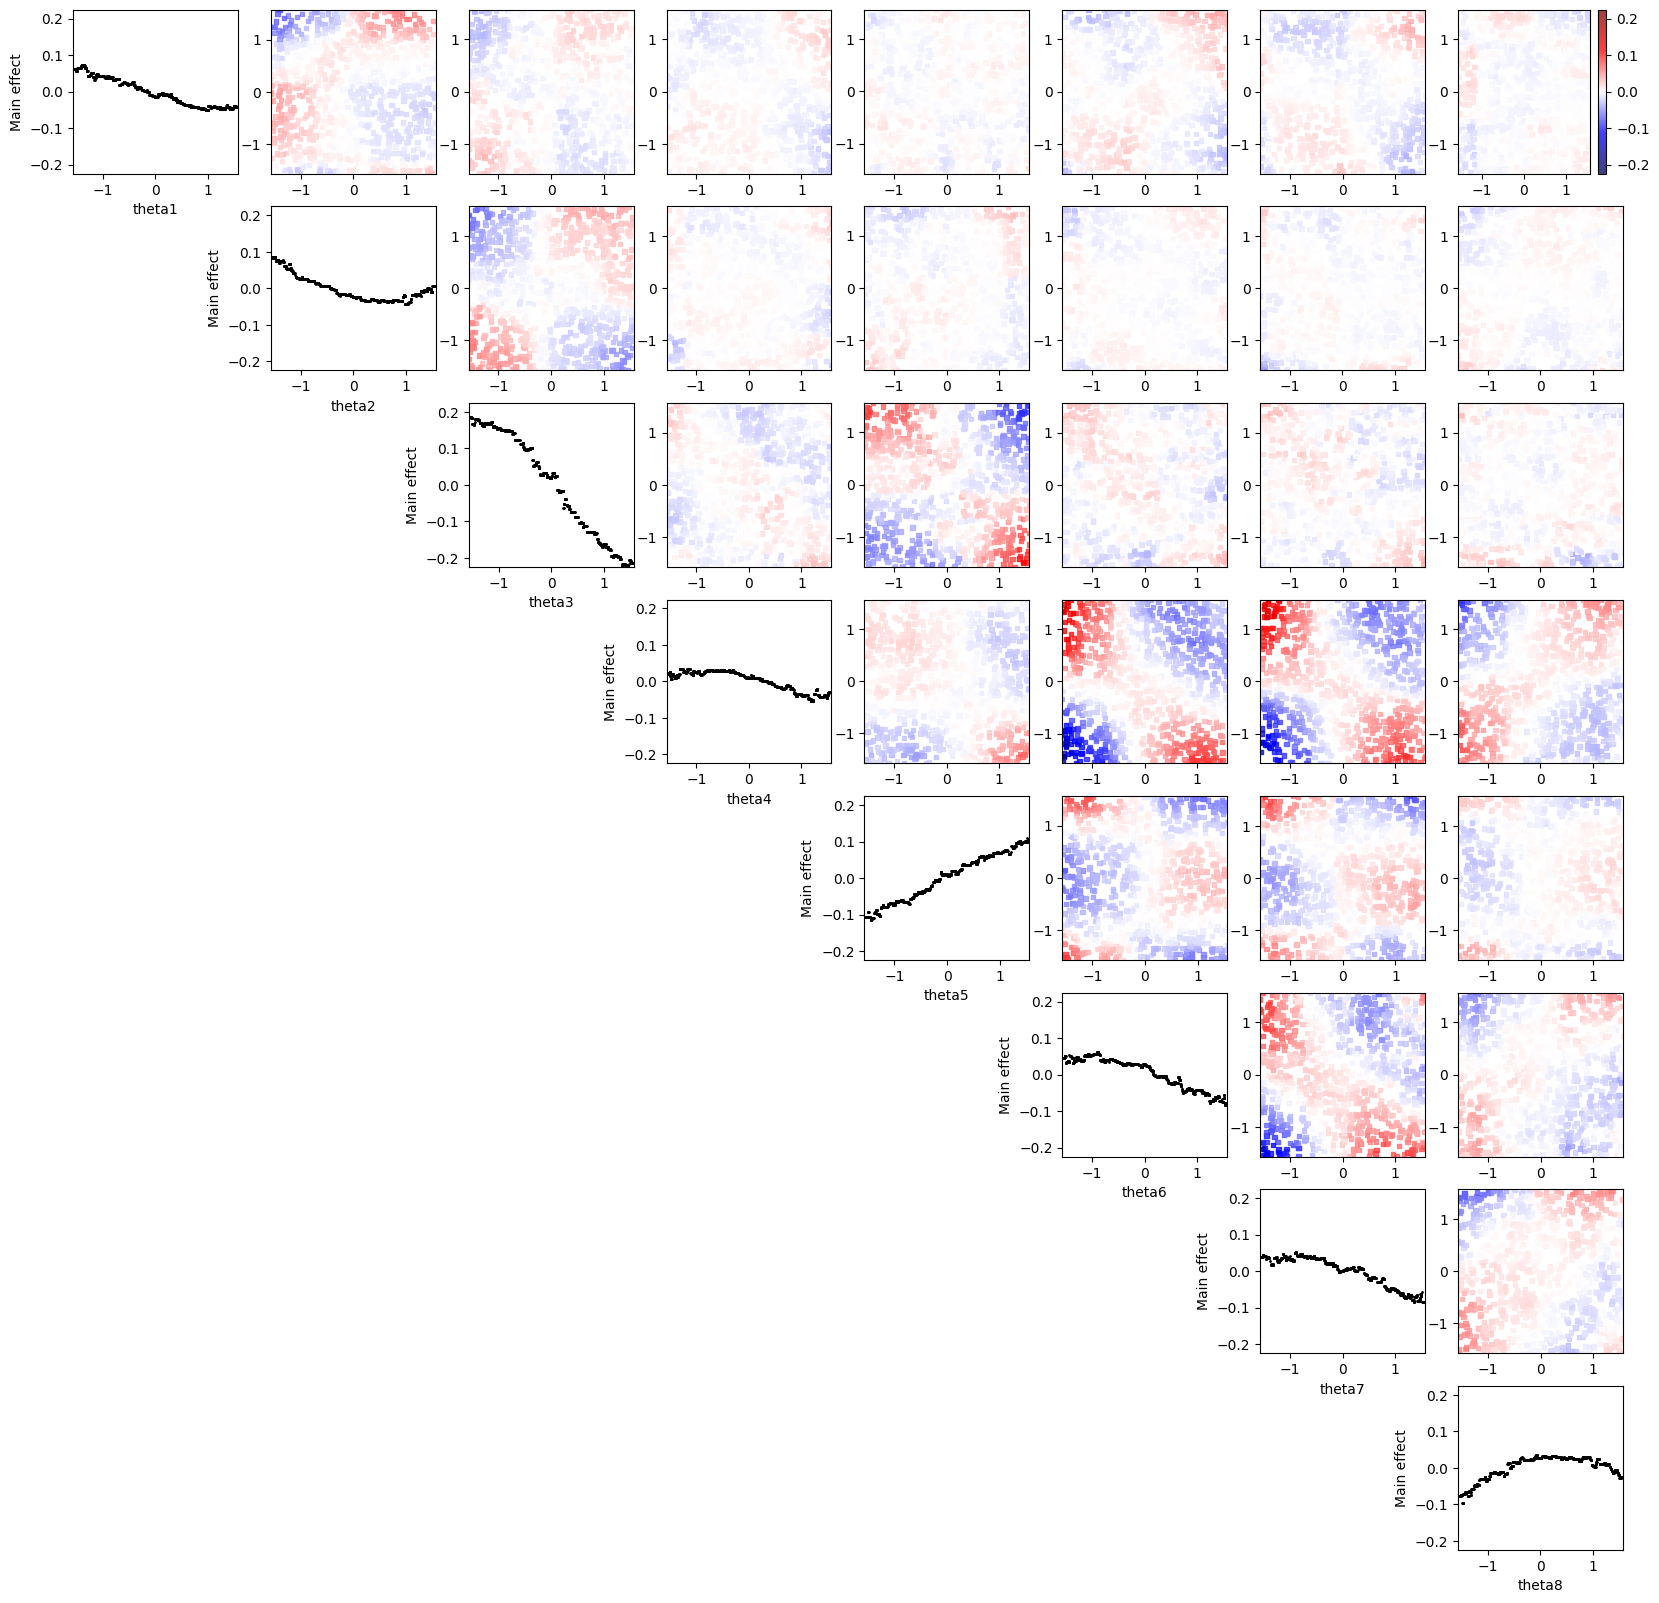

In [64]:
from typing import Union, List, Dict, Tuple
from matplotlib.colors import CenteredNorm

Decomposition = Dict[Tuple[int, ...], np.ndarray]

def plot_main_effect_and_interactions(decomposition: Union[Decomposition, List[Decomposition]], background: Union[np.ndarray, List[np.ndarray]], features):
    if isinstance(decomposition, dict):
        decompositions = [decomposition]
        backgrounds = [background]
        n_regions = 1
    else:
        n_regions = len(decomposition)
    
    # Parameters shared across figures
    max_abs_val = max([
                    max([
                        np.max(
                            np.abs(decomposition[key].mean(1))
                        ) for key in decomposition.keys() if len(key)> 0
                    ]) for decomposition in decompositions]
                )
    min_feature_value = np.zeros(len(features))
    max_feature_value = np.zeros(len(features))
    for i in range(len(features)):
        min_feature_value[i] = np.min([background[:, i].min() for background in backgrounds])
        max_feature_value[i] = np.min([background[:, i].max() for background in backgrounds])

    for r in range(n_regions):
        decomposition = decompositions[r]
        background = backgrounds[r]
        fig, axes = plt.subplots(len(features), len(features), figsize=(20, 20))
        # We plot the pure (0, 1) interaction from `region 1`
        for feature_1 in range(len(features)):
            for feature_2 in range(len(features)):
                curr_ax = axes[feature_1][feature_2]
                if feature_1 > feature_2:
                    curr_ax.remove()
                elif feature_1 == feature_2:
                    main_effect = decomposition[(feature_1,)].mean(1)
                    curr_ax.scatter(background[:, feature_1], main_effect, c='k', s=1)
                    curr_ax.set_xlabel(features.names()[feature_1])
                    curr_ax.set_ylabel('Main effect')
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(-max_abs_val, max_abs_val)
                else:
                    interactions = decomposition[(feature_1, feature_2)].mean(1),
                    cbar = curr_ax.scatter(background[:, feature_1], background[:, feature_2], c=interactions, s=10, marker="s",
                                                cmap='seismic', alpha=0.75, norm=CenteredNorm(0, halfrange=max_abs_val))
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(min_feature_value[feature_2], max_feature_value[feature_2])
        fig.colorbar(cbar, ax=axes[0, len(features)-1])


plot_main_effect_and_interactions(decomposition, background, features)

In [65]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# We minimize the pure-full interactions involving features x0 and x1
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=[(5, 6), (3, 6), (4, 6),(3, 5)]
)
tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=2, alpha=0.15)
tree.fit(background, loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If theta7 ≤ 0.2062:
|   Loss 0.1900
|   Samples 575
|   Region 0
else:
|   Loss 0.1517
|   Samples 425
|   Region 1
Final Loss 0.3417


In [66]:
# Using regional backgrounds
regions = tree.predict(background)
display(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
display(rules)
_, count = np.unique(regions, return_counts=True)
display(count)

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1], dtype=int32)

{0: 'theta7<=0.21', 1: 'theta7>0.21'}

array([575, 425])

In [76]:
# We compute regional decompositions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = background[regions==r]
regional_decomposition = get_regional_decompositions(decomposition, regions, regions, tree.n_regions)

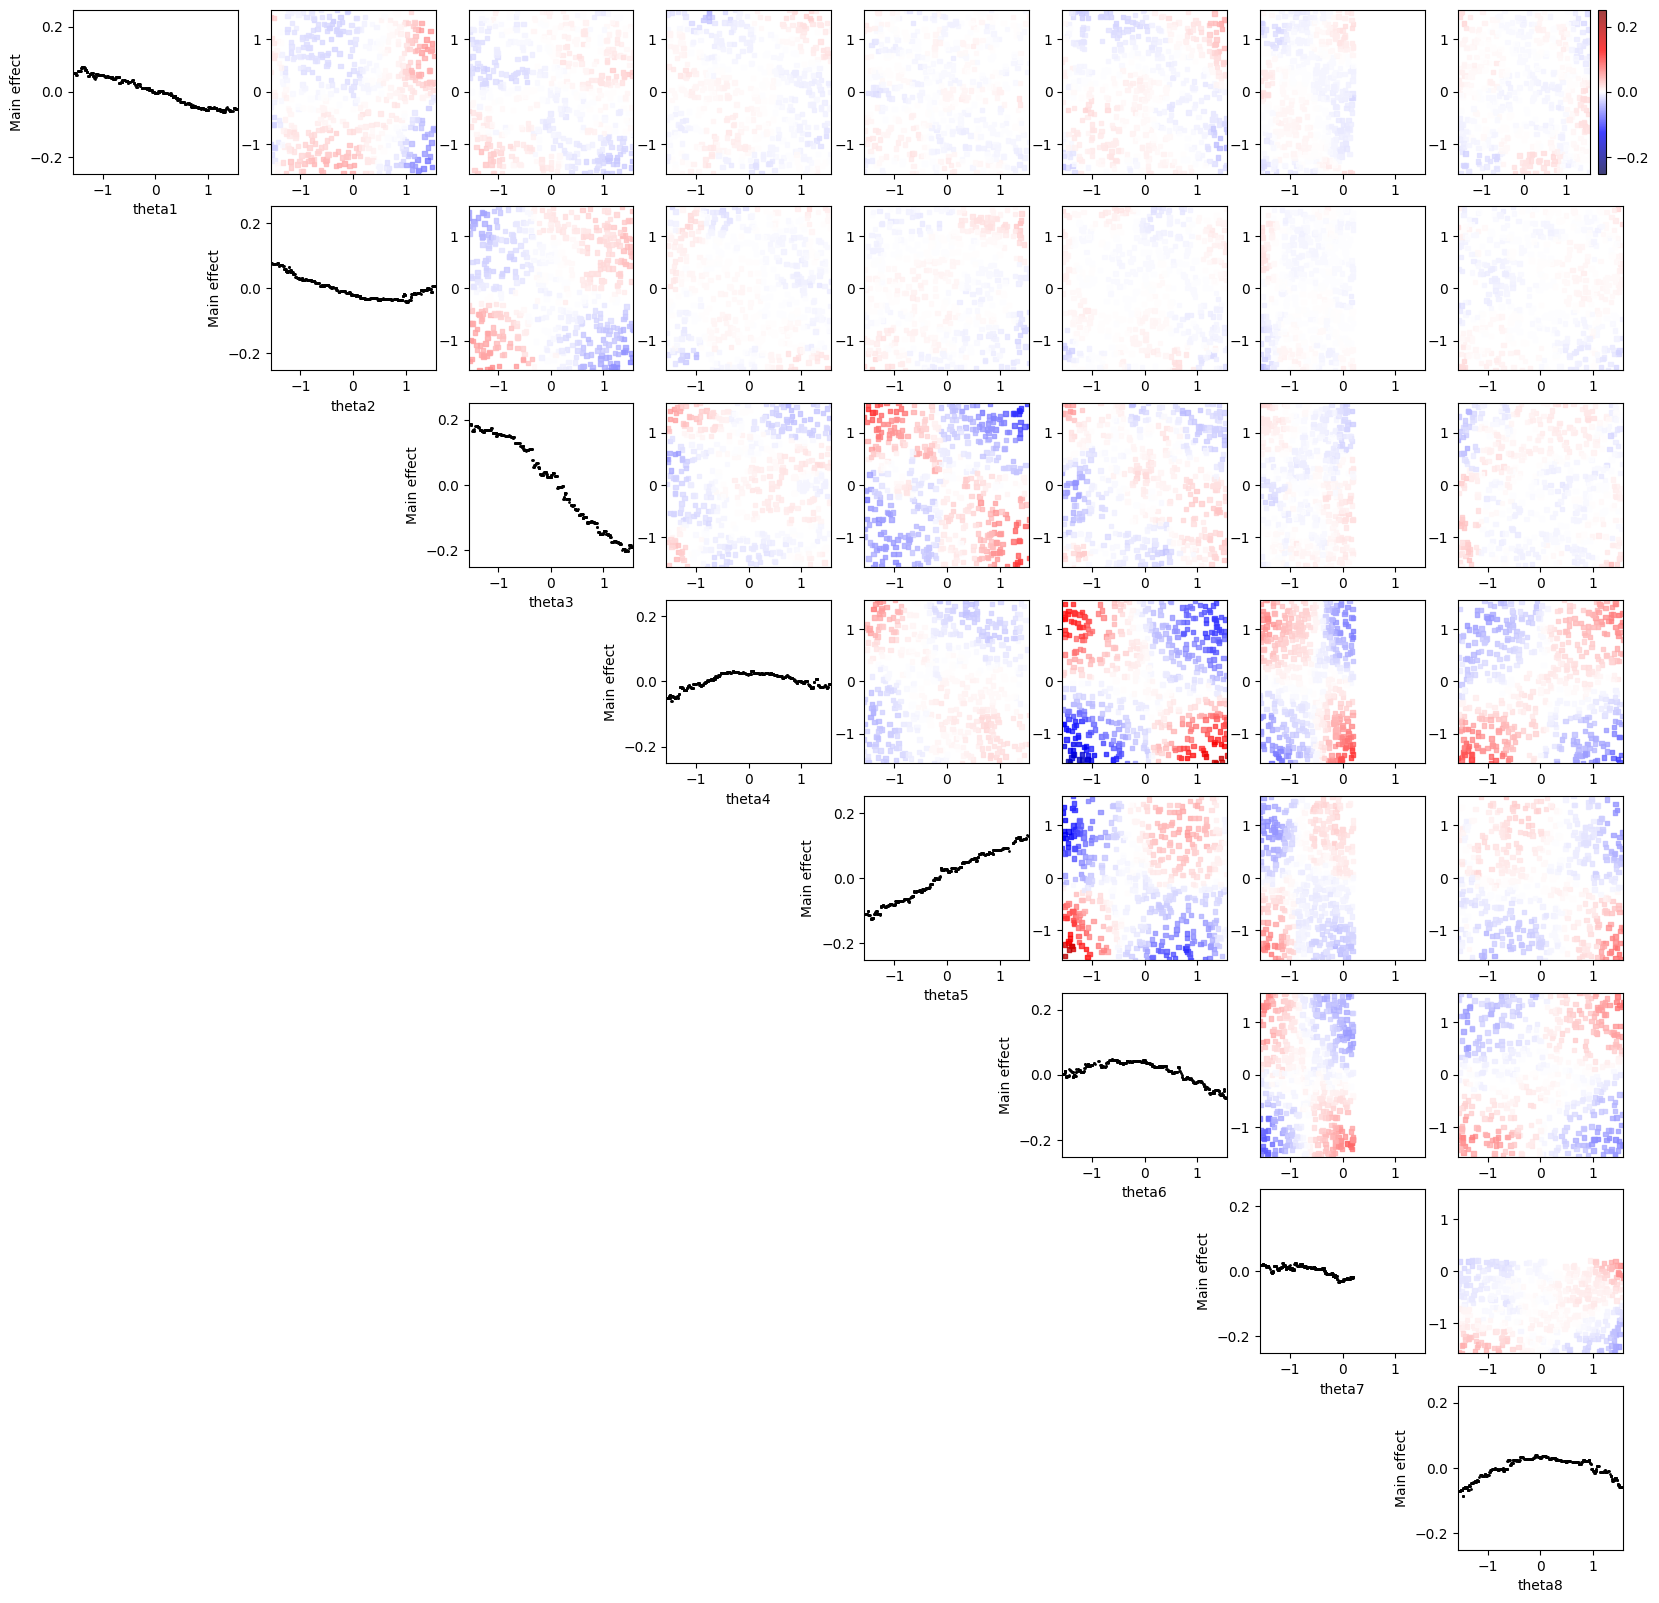

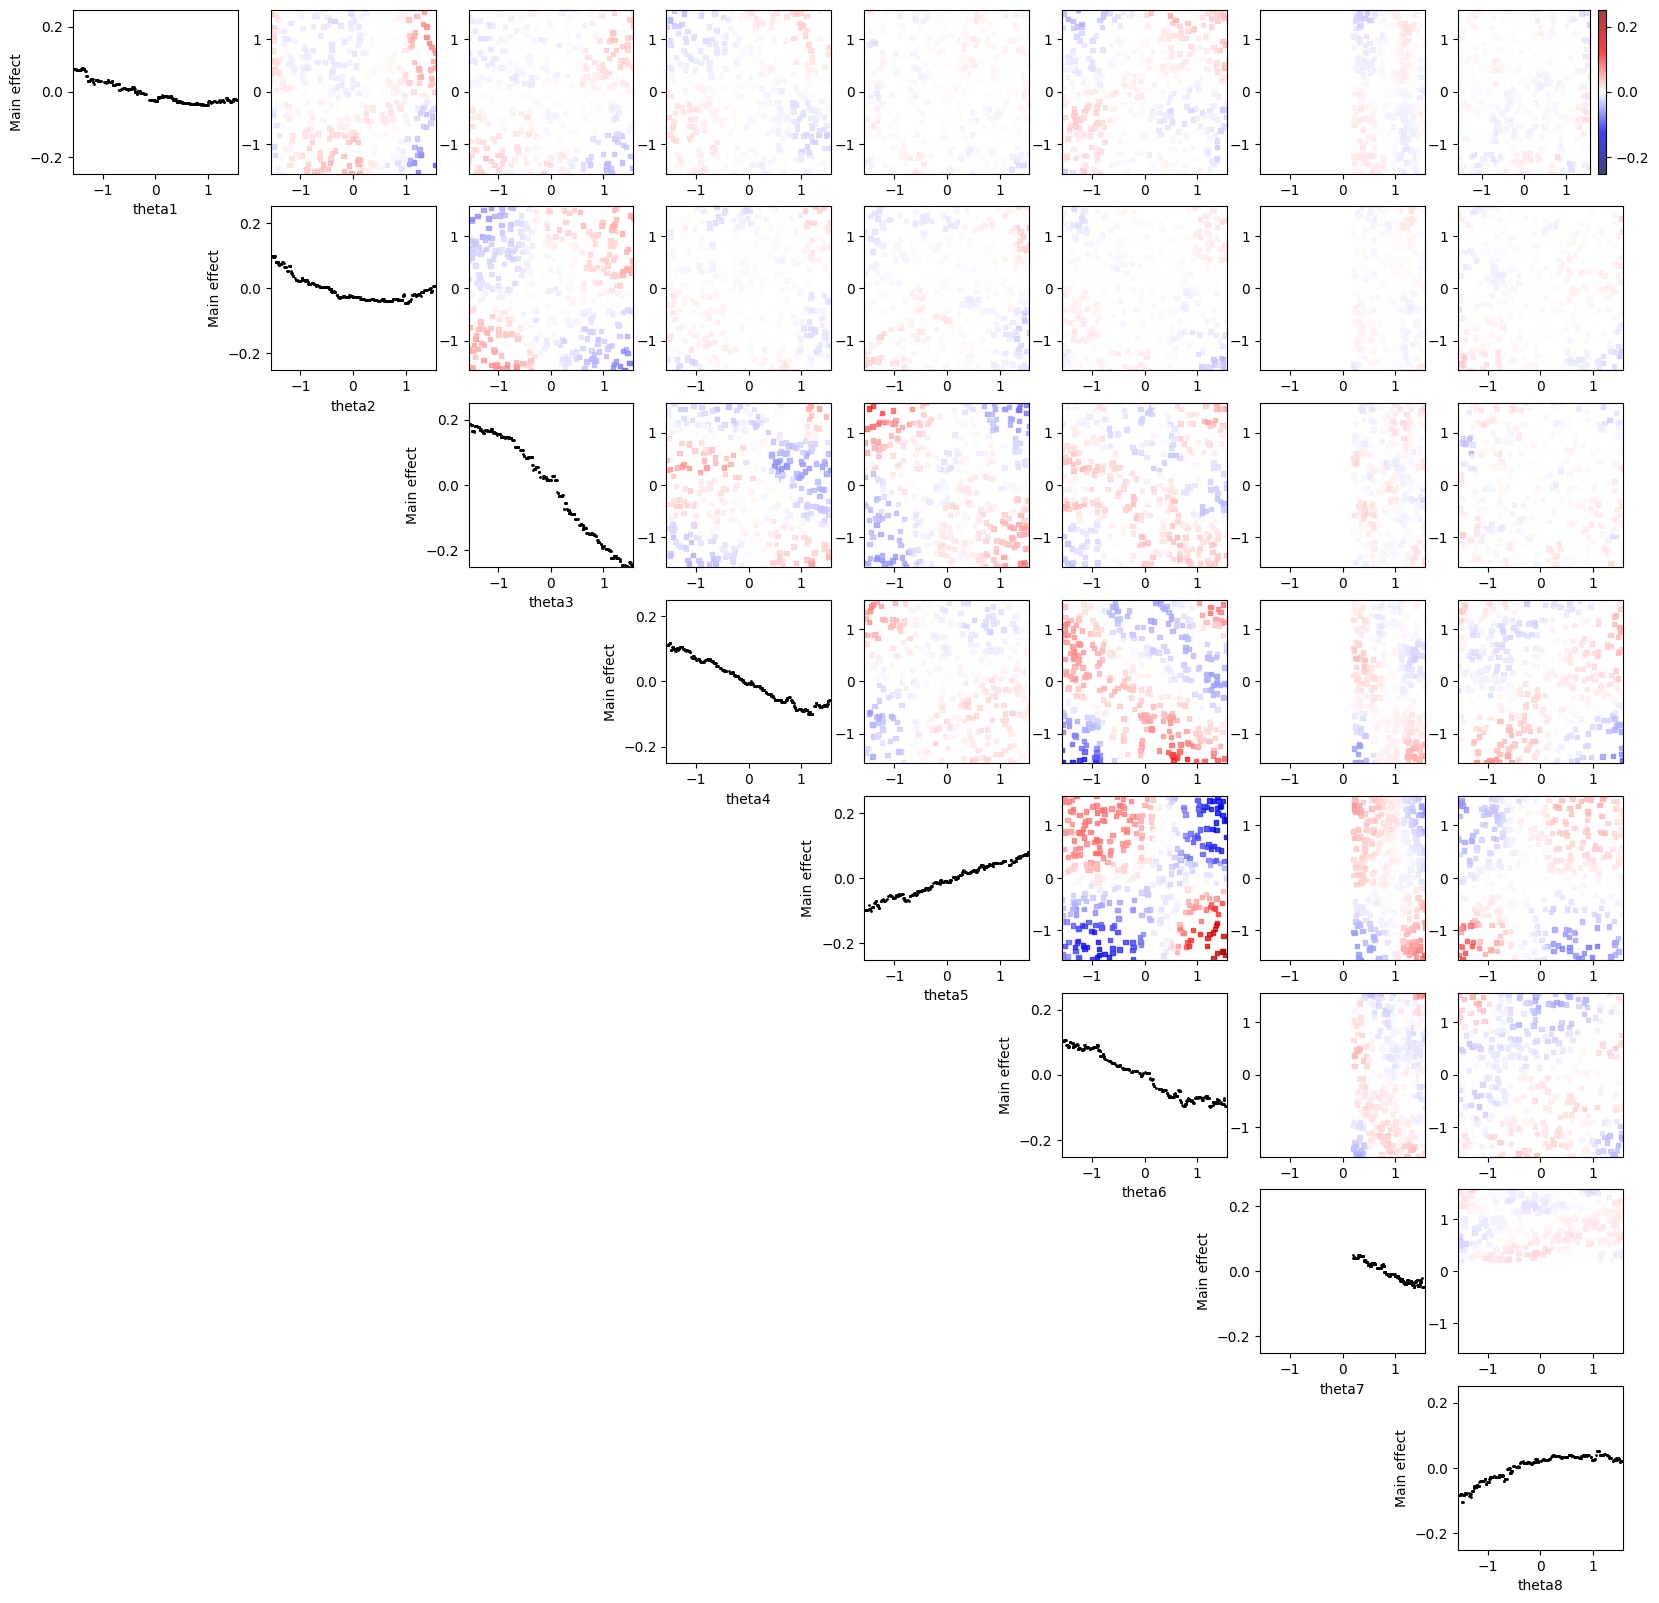

In [81]:
def plot_main_effect_and_interactions(decompositions: Union[Decomposition, List[Decomposition]], backgrounds: Union[np.ndarray, List[np.ndarray]], features):
    if isinstance(decompositions, dict):
        decompositions = [decompositions]
        backgrounds = [backgrounds]
        n_regions = 1
    else:
        n_regions = len(decompositions)
    
    # Parameters shared across figures
    max_abs_val = max([
                    max([
                        np.max(
                            np.abs(decomposition[key].mean(1))
                        ) for key in decomposition.keys() if len(key)> 0
                    ]) for decomposition in decompositions]
                )
    min_feature_value = np.zeros(len(features))
    max_feature_value = np.zeros(len(features))
    for i in range(len(features)):
        min_feature_value[i] = np.min([background[:, i].min() for background in backgrounds])
        max_feature_value[i] = np.max([background[:, i].max() for background in backgrounds])

    for r in range(n_regions):
        decomposition = decompositions[r]
        background = backgrounds[r]
        fig, axes = plt.subplots(len(features), len(features), figsize=(20, 20))
        # We plot the pure (0, 1) interaction from `region 1`
        for feature_1 in range(len(features)):
            for feature_2 in range(len(features)):
                curr_ax = axes[feature_1][feature_2]
                if feature_1 > feature_2:
                    curr_ax.remove()
                elif feature_1 == feature_2:
                    main_effect = decomposition[(feature_1,)].mean(1)
                    curr_ax.scatter(background[:, feature_1], main_effect, c='k', s=1)
                    curr_ax.set_xlabel(features.names()[feature_1])
                    curr_ax.set_ylabel('Main effect')
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(-max_abs_val, max_abs_val)
                else:
                    interactions = decomposition[(feature_1, feature_2)].mean(1),
                    cbar = curr_ax.scatter(background[:, feature_2], background[:, feature_1], c=interactions, s=10, marker="s",
                                                cmap='seismic', alpha=0.75, norm=CenteredNorm(0, halfrange=max_abs_val))
                    curr_ax.set_xlim(min_feature_value[feature_2], max_feature_value[feature_2])
                    curr_ax.set_ylim(min_feature_value[feature_1], max_feature_value[feature_1])
        fig.colorbar(cbar, ax=axes[0, len(features)-1])

plot_main_effect_and_interactions(regional_decomposition, regional_backgrounds, features)
